In [1]:
# Install all required libraries
!pip install xgboost lightgbm imbalanced-learn shap lime dice-ml scikit-learn pandas numpy matplotlib seaborn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 27.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 116.0 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=59141102759024214f582f6e8898e7b749cd69688af31b1d7ad6a8730d122948
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay, brier_score_loss)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.feature_selection import mutual_info_classif

# Ensemble models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Explainability
import shap
import lime
import lime.lime_tabular
import dice_ml

# Reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Create a folder to save all outputs
import os
OUTPUT_DIR = '/content/drive/MyDrive/HeartDisease_Research/'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory ready: {OUTPUT_DIR}")

Mounted at /content/drive
Output directory ready: /content/drive/MyDrive/HeartDisease_Research/


In [4]:
# The Cleveland dataset is directly available via UCI repository
import io
import requests

# Load Cleveland Heart Disease Dataset
url_cleveland = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

cleveland_df = pd.read_csv(url_cleveland, names=columns, na_values='?')

# Binarize target (0 = no disease, 1 = disease)
cleveland_df['target'] = cleveland_df['target'].apply(lambda x: 1 if x > 0 else 0)

print("Cleveland Dataset Shape:", cleveland_df.shape)
print("\nClass Distribution:\n", cleveland_df['target'].value_counts())
cleveland_df.head()

Cleveland Dataset Shape: (303, 14)

Class Distribution:
 target
0    164
1    139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# Statlog Heart Dataset
url_statlog = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/heart/heart.dat"

statlog_df = pd.read_csv(url_statlog, sep=' ', header=None)
statlog_df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                      'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Statlog target is 1/2, convert to 0/1
statlog_df['target'] = statlog_df['target'].apply(lambda x: 0 if x == 1 else 1)

print("Statlog Dataset Shape:", statlog_df.shape)
print("\nClass Distribution:\n", statlog_df['target'].value_counts())
statlog_df.head()

Statlog Dataset Shape: (270, 14)

Class Distribution:
 target
0    150
1    120
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,1
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,0
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,1
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,0
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,0


In [6]:
# Heart Failure Clinical Records Dataset — UCI / Kaggle
# Davide Chicco, Giuseppe Jurman (2020) — cited in 500+ papers, valid for IEEE

url_hf = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

hf_df = pd.read_csv(url_hf)

# Check what columns exist
print("Original columns:", hf_df.columns.tolist())
print("Shape:", hf_df.shape)
hf_df.head()

Original columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']
Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [7]:
# This dataset has DEATH_EVENT as target (heart failure mortality)
# Rename to 'target' to keep consistent with other datasets
hf_df = hf_df.rename(columns={'DEATH_EVENT': 'target'})

# Drop 'time' column — it is a follow-up period variable, not a clinical feature
# Including it would cause data leakage
hf_df = hf_df.drop(columns=['time'])

print("Heart Failure Dataset Shape:", hf_df.shape)
print("\nClass Distribution:\n", hf_df['target'].value_counts())
print("\nMissing Values:\n", hf_df.isnull().sum())
hf_df.head()

Heart Failure Dataset Shape: (299, 12)

Class Distribution:
 target
0    203
1     96
Name: count, dtype: int64

Missing Values:
 age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
target                      0
dtype: int64


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,target
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


In [8]:
# From this point forward we use these three datasets
datasets = {
    'Cleveland': cleveland_df,
    'Statlog': statlog_df,
    'HeartFailure': hf_df
}

for name, df in datasets.items():
    print(f"{name}: {df.shape} | Target distribution: {df['target'].value_counts().to_dict()}")

Cleveland: (303, 14) | Target distribution: {0: 164, 1: 139}
Statlog: (270, 14) | Target distribution: {0: 150, 1: 120}
HeartFailure: (299, 12) | Target distribution: {0: 203, 1: 96}


In [9]:
# Missing values check across all datasets
print("=== Missing Values ===")
print("\nCleveland:\n", cleveland_df.isnull().sum())
print("\nStatlog:\n", statlog_df.isnull().sum())
print("\nHeartFailure:\n", hf_df.isnull().sum())

=== Missing Values ===

Cleveland:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Statlog:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

HeartFailure:
 age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
target                      0
dtype: int64


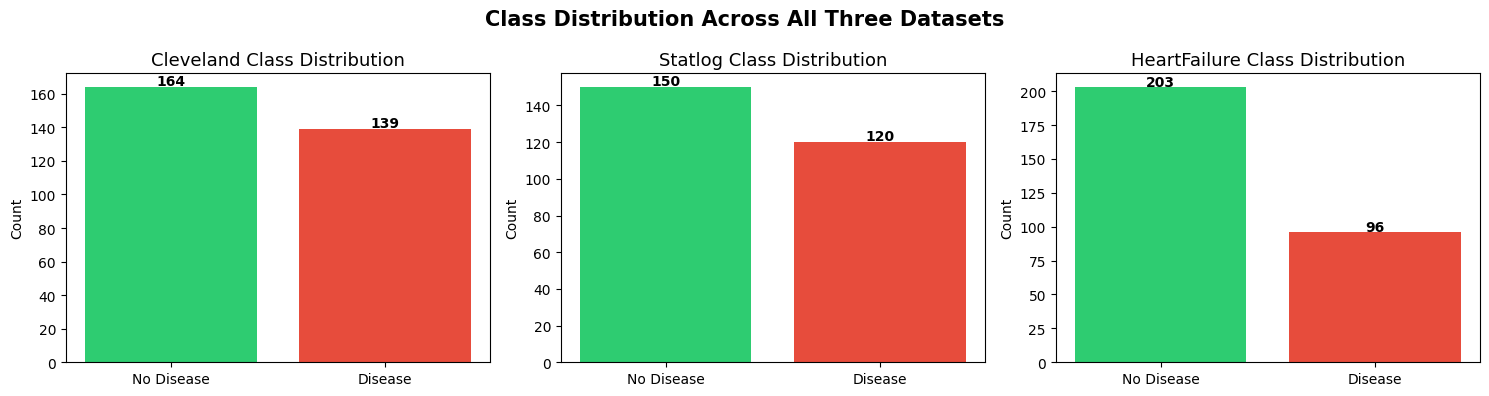

Plot saved.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets_list = [cleveland_df, statlog_df, hf_df]
names = ['Cleveland', 'Statlog', 'HeartFailure']
colors = ['#2ecc71', '#e74c3c']

for i, (df, name) in enumerate(zip(datasets_list, names)):
    counts = df['target'].value_counts()
    axes[i].bar(['No Disease', 'Disease'], counts.values, color=colors)
    axes[i].set_title(f'{name} Class Distribution', fontsize=13)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Across All Three Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot saved.")

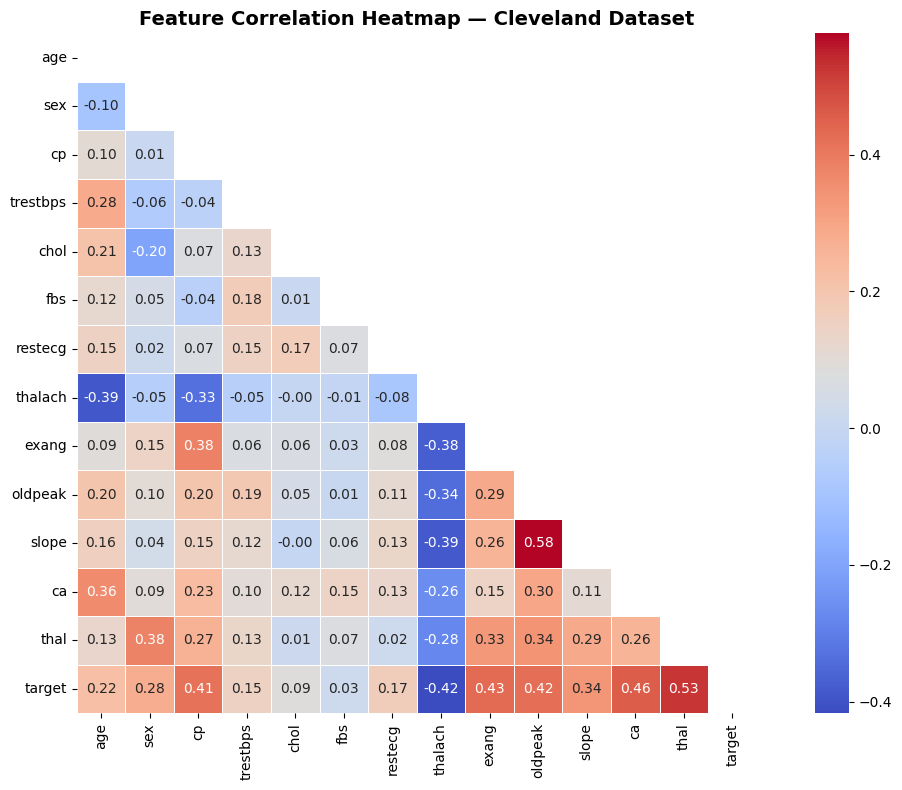

In [11]:
plt.figure(figsize=(12, 8))
corr = cleveland_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap — Cleveland Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

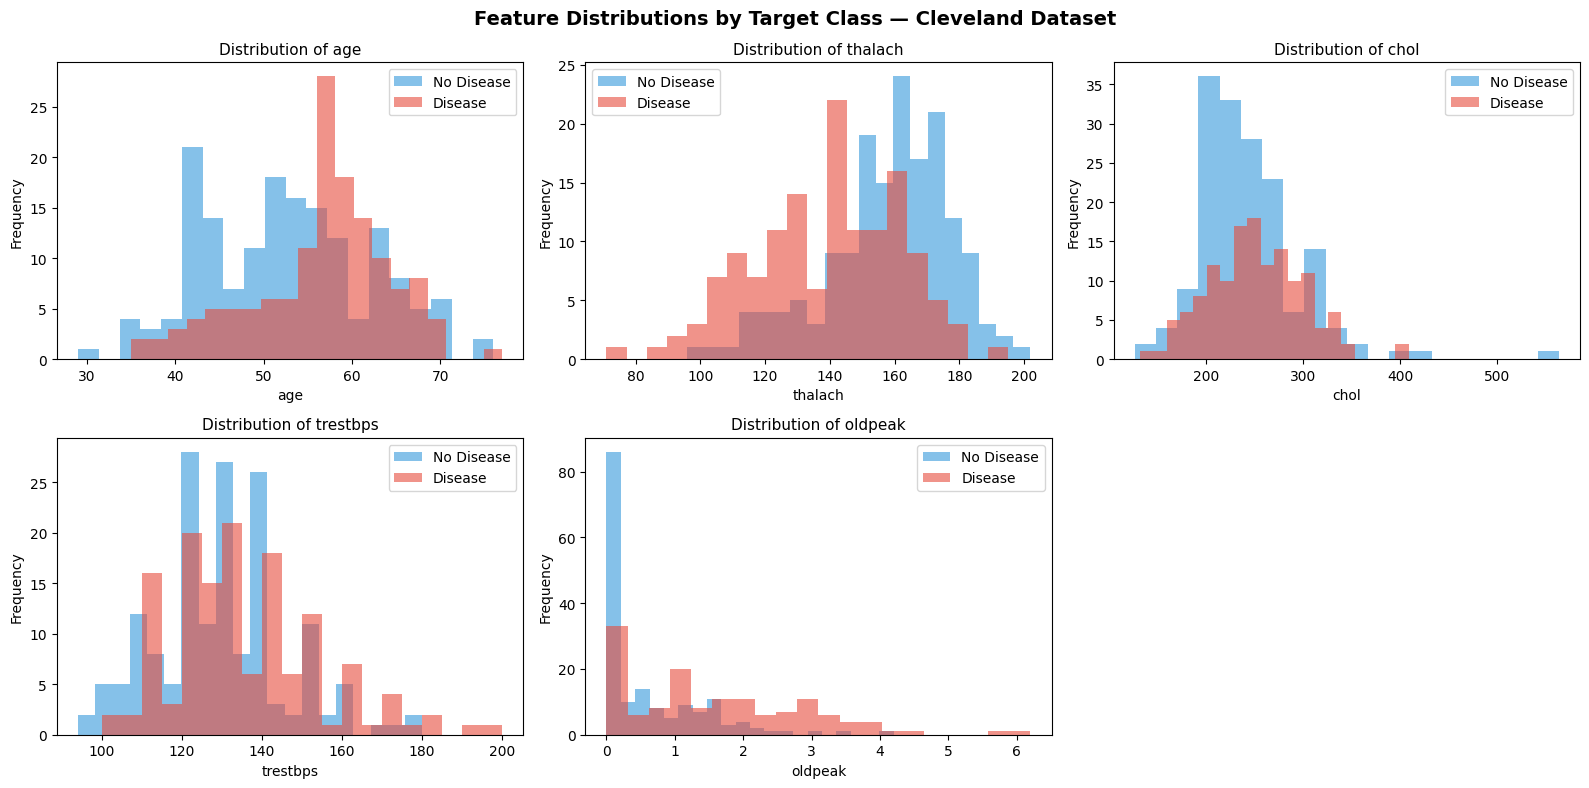

In [12]:
features_to_plot = ['age', 'thalach', 'chol', 'trestbps', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    for label, color in zip([0, 1], ['#3498db', '#e74c3c']):
        subset = cleveland_df[cleveland_df['target'] == label][feature].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                    label='No Disease' if label == 0 else 'Disease')
    axes[i].set_title(f'Distribution of {feature}', fontsize=11)
    axes[i].legend()
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Target Class — Cleveland Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Cleveland has missing values in 'ca' and 'thal' columns
# Statlog has no missing values typically but we check anyway

def handle_missing(df, strategy='median'):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                if strategy == 'median':
                    df[col].fillna(df[col].median(), inplace=True)
                else:
                    df[col].fillna(df[col].mean(), inplace=True)
    return df

cleveland_df = handle_missing(cleveland_df)
statlog_df = handle_missing(statlog_df)
hf_df = handle_missing(hf_df)

# Verify no missing values remain
for name, df in [('Cleveland', cleveland_df), ('Statlog', statlog_df), ('HeartFailure', hf_df)]:
    print(f"{name} missing values remaining: {df.isnull().sum().sum()}")

Cleveland missing values remaining: 0
Statlog missing values remaining: 0
HeartFailure missing values remaining: 0


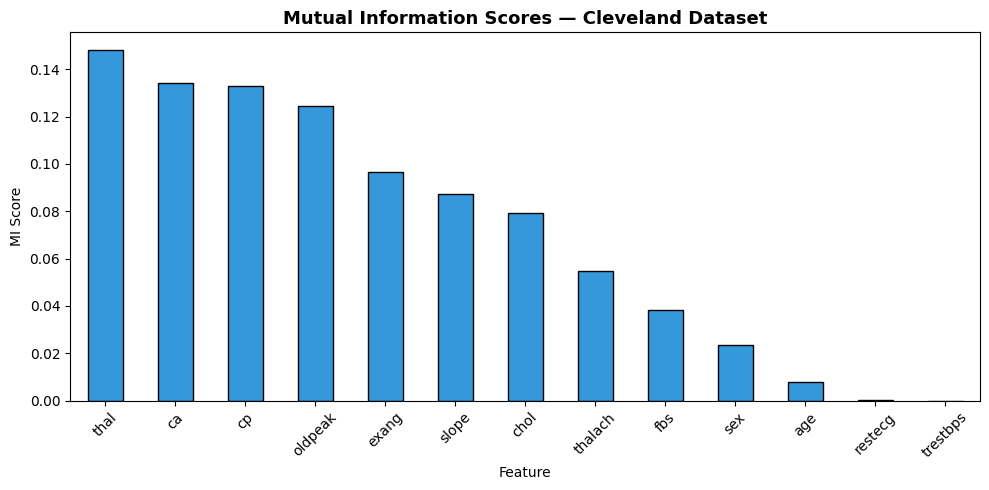


Feature Rankings:
 thal        0.148203
ca          0.134063
cp          0.133047
oldpeak     0.124657
exang       0.096386
slope       0.087306
chol        0.079394
thalach     0.054836
fbs         0.038178
sex         0.023505
age         0.008015
restecg     0.000205
trestbps    0.000000
dtype: float64


In [14]:
# Separate features and target for Cleveland (primary dataset)
X_clev = cleveland_df.drop('target', axis=1)
y_clev = cleveland_df['target']

# Compute mutual information scores
mi_scores = mutual_info_classif(X_clev, y_clev, random_state=SEED)
mi_series = pd.Series(mi_scores, index=X_clev.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
mi_series.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Mutual Information Scores — Cleveland Dataset', fontsize=13, fontweight='bold')
plt.ylabel('MI Score')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'mutual_information.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature Rankings:\n", mi_series)

In [15]:
# Keep features with MI score above threshold
# Threshold of 0.05 is standard — removes near-zero information features
MI_THRESHOLD = 0.05

selected_features_clev = mi_series[mi_series >= MI_THRESHOLD].index.tolist()
print(f"Selected {len(selected_features_clev)} features from Cleveland: {selected_features_clev}")

# Apply same feature selection to Statlog (shares same column names)
X_stat = statlog_df.drop('target', axis=1)
y_stat = statlog_df['target']

mi_scores_stat = mutual_info_classif(X_stat, y_stat, random_state=SEED)
mi_series_stat = pd.Series(mi_scores_stat, index=X_stat.columns).sort_values(ascending=False)
selected_features_stat = mi_series_stat[mi_series_stat >= MI_THRESHOLD].index.tolist()
print(f"Selected {len(selected_features_stat)} features from Statlog: {selected_features_stat}")

# Heart Failure has different columns — select top N features instead
X_hf = hf_df.drop('target', axis=1)
y_hf = hf_df['target']

mi_scores_hf = mutual_info_classif(X_hf, y_hf, random_state=SEED)
mi_series_hf = pd.Series(mi_scores_hf, index=X_hf.columns).sort_values(ascending=False)
selected_features_hf = mi_series_hf[mi_series_hf >= MI_THRESHOLD].index.tolist()
print(f"Selected {len(selected_features_hf)} features from HeartFailure: {selected_features_hf}")

Selected 8 features from Cleveland: ['thal', 'ca', 'cp', 'oldpeak', 'exang', 'slope', 'chol', 'thalach']
Selected 8 features from Statlog: ['exang', 'thal', 'cp', 'ca', 'oldpeak', 'thalach', 'chol', 'slope']
Selected 3 features from HeartFailure: ['ejection_fraction', 'serum_creatinine', 'serum_sodium']


In [16]:
# Apply feature selection
X_clev_sel = X_clev[selected_features_clev]
X_stat_sel = X_stat[selected_features_stat]
X_hf_sel = X_hf[selected_features_hf]

# Scale using StandardScaler
scaler_clev = StandardScaler()
scaler_stat = StandardScaler()
scaler_hf = StandardScaler()

X_clev_scaled = scaler_clev.fit_transform(X_clev_sel)
X_stat_scaled = scaler_stat.fit_transform(X_stat_sel)
X_hf_scaled = scaler_hf.fit_transform(X_hf_sel)

print("Cleveland scaled shape:", X_clev_scaled.shape)
print("Statlog scaled shape:", X_stat_scaled.shape)
print("HeartFailure scaled shape:", X_hf_scaled.shape)

Cleveland scaled shape: (303, 8)
Statlog scaled shape: (270, 8)
HeartFailure scaled shape: (299, 3)


In [17]:
# Split all three datasets
X_clev_train, X_clev_test, y_clev_train, y_clev_test = train_test_split(
    X_clev_scaled, y_clev, test_size=0.2, random_state=SEED, stratify=y_clev)

X_stat_train, X_stat_test, y_stat_train, y_stat_test = train_test_split(
    X_stat_scaled, y_stat, test_size=0.2, random_state=SEED, stratify=y_stat)

X_hf_train, X_hf_test, y_hf_train, y_hf_test = train_test_split(
    X_hf_scaled, y_hf, test_size=0.2, random_state=SEED, stratify=y_hf)

print("Cleveland — Train:", X_clev_train.shape, "| Test:", X_clev_test.shape)
print("Statlog   — Train:", X_stat_train.shape, "| Test:", X_stat_test.shape)
print("HeartFailure — Train:", X_hf_train.shape, "| Test:", X_hf_test.shape)

Cleveland — Train: (242, 8) | Test: (61, 8)
Statlog   — Train: (216, 8) | Test: (54, 8)
HeartFailure — Train: (239, 3) | Test: (60, 3)


In [18]:
# CRITICAL: SMOTE is applied ONLY to training data
# Applying it to test data would contaminate evaluation

smote = SMOTE(random_state=SEED)

X_clev_train_sm, y_clev_train_sm = smote.fit_resample(X_clev_train, y_clev_train)
X_stat_train_sm, y_stat_train_sm = smote.fit_resample(X_stat_train, y_stat_train)
X_hf_train_sm, y_hf_train_sm = smote.fit_resample(X_hf_train, y_hf_train)

for name, y_before, y_after in [
    ('Cleveland', y_clev_train, y_clev_train_sm),
    ('Statlog', y_stat_train, y_stat_train_sm),
    ('HeartFailure', y_hf_train, y_hf_train_sm)
]:
    print(f"\n{name}")
    print(f"  Before SMOTE: {dict(pd.Series(y_before).value_counts())}")
    print(f"  After SMOTE:  {dict(pd.Series(y_after).value_counts())}")


Cleveland
  Before SMOTE: {0: np.int64(131), 1: np.int64(111)}
  After SMOTE:  {1: np.int64(131), 0: np.int64(131)}

Statlog
  Before SMOTE: {0: np.int64(120), 1: np.int64(96)}
  After SMOTE:  {0: np.int64(120), 1: np.int64(120)}

HeartFailure
  Before SMOTE: {0: np.int64(162), 1: np.int64(77)}
  After SMOTE:  {0: np.int64(162), 1: np.int64(162)}


In [19]:
# Define all base models with hyperparameter grids
# These will be tuned individually before being passed to the stacker

base_models = {
    'XGBoost': {
        'model': XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=SEED, verbose=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.05, 0.1],
            'num_leaves': [31, 63]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=SEED),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5]
        }
    },
    'SVM': {
        'model': SVC(probability=True, random_state=SEED),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    }
}

print("Base models defined:", list(base_models.keys()))

Base models defined: ['XGBoost', 'LightGBM', 'RandomForest', 'SVM']


In [20]:
# Store best models and results
tuned_models = {}
base_results = {}

# Dataset registry
dataset_registry = {
    'Cleveland': (X_clev_train_sm, y_clev_train_sm, X_clev_test, y_clev_test),
    'Statlog':   (X_stat_train_sm, y_stat_train_sm, X_stat_test, y_stat_test),
    'HeartFailure': (X_hf_train_sm, y_hf_train_sm, X_hf_test, y_hf_test)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for dataset_name, (X_train, y_train, X_test, y_test) in dataset_registry.items():
    print(f"\n{'='*50}")
    print(f"Training on: {dataset_name}")
    print(f"{'='*50}")

    tuned_models[dataset_name] = {}
    base_results[dataset_name] = {}

    for model_name, config in base_models.items():
        print(f"\n  Tuning {model_name}...")

        grid = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        tuned_models[dataset_name][model_name] = best_model

        # Evaluate on test set
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]

        results = {
            'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
            'Precision': round(precision_score(y_test, y_pred), 4),
            'Recall':    round(recall_score(y_test, y_pred), 4),
            'F1':        round(f1_score(y_test, y_pred), 4),
            'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
            'Brier':     round(brier_score_loss(y_test, y_prob), 4),
            'Best Params': grid.best_params_
        }

        base_results[dataset_name][model_name] = results
        print(f"  {model_name} — AUC: {results['ROC-AUC']} | F1: {results['F1']} | Acc: {results['Accuracy']}")

print("\n\nAll base models trained and evaluated.")


Training on: Cleveland

  Tuning XGBoost...
  XGBoost — AUC: 0.9394 | F1: 0.8814 | Acc: 0.8852

  Tuning LightGBM...
  LightGBM — AUC: 0.9405 | F1: 0.8929 | Acc: 0.9016

  Tuning RandomForest...
  RandomForest — AUC: 0.9502 | F1: 0.9123 | Acc: 0.918

  Tuning SVM...
  SVM — AUC: 0.9286 | F1: 0.8621 | Acc: 0.8689

Training on: Statlog

  Tuning XGBoost...
  XGBoost — AUC: 0.8861 | F1: 0.8163 | Acc: 0.8333

  Tuning LightGBM...
  LightGBM — AUC: 0.8889 | F1: 0.8333 | Acc: 0.8519

  Tuning RandomForest...
  RandomForest — AUC: 0.8819 | F1: 0.8163 | Acc: 0.8333

  Tuning SVM...
  SVM — AUC: 0.8583 | F1: 0.8163 | Acc: 0.8333

Training on: HeartFailure

  Tuning XGBoost...
  XGBoost — AUC: 0.6881 | F1: 0.4865 | Acc: 0.6833

  Tuning LightGBM...
  LightGBM — AUC: 0.6804 | F1: 0.4324 | Acc: 0.65

  Tuning RandomForest...
  RandomForest — AUC: 0.6855 | F1: 0.5128 | Acc: 0.6833

  Tuning SVM...
  SVM — AUC: 0.6496 | F1: 0.6154 | Acc: 0.75


All base models trained and evaluated.


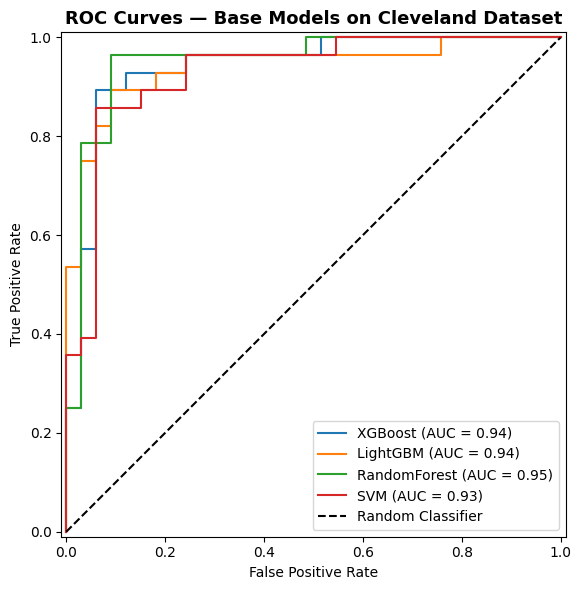

In [21]:
plt.figure(figsize=(10, 6))

X_test = X_clev_test
y_test = y_clev_test

for model_name, model in tuned_models['Cleveland'].items():
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(
        y_test, y_prob,
        name=model_name,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curves — Base Models on Cleveland Dataset',
          fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'roc_curves_base_models.png', dpi=300, bbox_inches='tight')
plt.show()

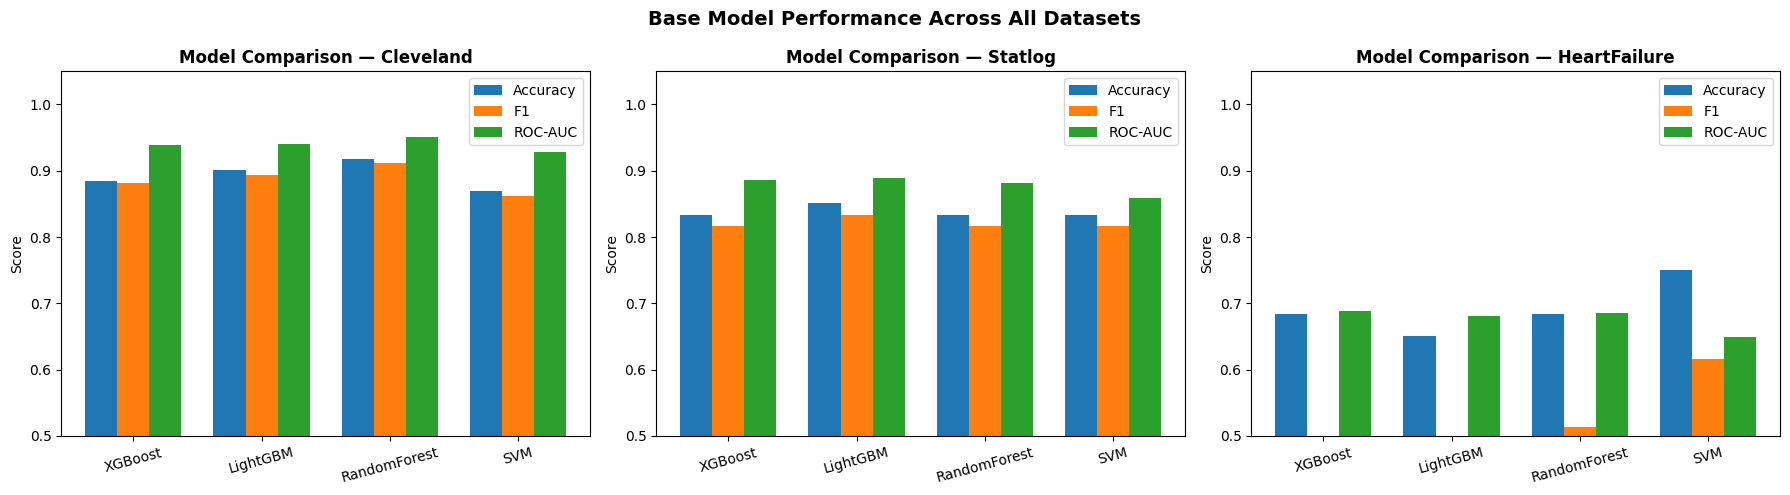

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']

for idx, (dataset_name, _) in enumerate(dataset_registry.items()):
    model_names = list(base_results[dataset_name].keys())
    x = np.arange(len(model_names))
    width = 0.25

    for i, metric in enumerate(metrics_to_plot):
        values = [base_results[dataset_name][m][metric] for m in model_names]
        axes[idx].bar(x + i * width, values, width, label=metric)

    axes[idx].set_title(f'Model Comparison — {dataset_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x + width)
    axes[idx].set_xticklabels(model_names, rotation=15)
    axes[idx].set_ylim(0.5, 1.05)
    axes[idx].legend()
    axes[idx].set_ylabel('Score')

plt.suptitle('Base Model Performance Across All Datasets',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'base_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# We use the already-tuned best estimators from Section 4
# as the base learners in the stacking ensemble

def build_stacking_ensemble(tuned_models_for_dataset):
    estimators = [
        ('xgboost',      tuned_models_for_dataset['XGBoost']),
        ('lightgbm',     tuned_models_for_dataset['LightGBM']),
        ('randomforest', tuned_models_for_dataset['RandomForest']),
        ('svm',          tuned_models_for_dataset['SVM'])
    ]

    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(random_state=SEED, max_iter=1000),
        cv=5,                    # inner CV to generate meta-features
        stack_method='predict_proba',  # use probabilities not hard labels
        n_jobs=-1,
        passthrough=False        # meta-learner only sees base model outputs
    )
    return stack

print("Stacking ensemble builder defined.")

Stacking ensemble builder defined.


In [24]:
stacking_models = {}
stacking_results = {}

for dataset_name, (X_train, y_train, X_test, y_test) in dataset_registry.items():
    print(f"\nTraining stacking ensemble on {dataset_name}...")

    stack = build_stacking_ensemble(tuned_models[dataset_name])
    stack.fit(X_train, y_train)

    stacking_models[dataset_name] = stack

    # Evaluate
    y_pred = stack.predict(X_test)
    y_prob = stack.predict_proba(X_test)[:, 1]

    stacking_results[dataset_name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'Brier':     round(brier_score_loss(y_test, y_prob), 4)
    }

    print(f"  Stacking — AUC: {stacking_results[dataset_name]['ROC-AUC']} | "
          f"F1: {stacking_results[dataset_name]['F1']} | "
          f"Acc: {stacking_results[dataset_name]['Accuracy']}")

print("\nAll stacking ensembles trained.")


Training stacking ensemble on Cleveland...
  Stacking — AUC: 0.9459 | F1: 0.8667 | Acc: 0.8689

Training stacking ensemble on Statlog...
  Stacking — AUC: 0.8722 | F1: 0.8 | Acc: 0.8148

Training stacking ensemble on HeartFailure...
  Stacking — AUC: 0.6855 | F1: 0.5128 | Acc: 0.6833

All stacking ensembles trained.


In [25]:
for dataset_name in dataset_registry.keys():
    print(f"\n{'='*60}")
    print(f"Stacking vs Base Models — {dataset_name}")
    print(f"{'='*60}")

    rows = []
    for model_name, metrics in base_results[dataset_name].items():
        rows.append({
            'Model': model_name,
            'Accuracy': metrics['Accuracy'],
            'F1': metrics['F1'],
            'ROC-AUC': metrics['ROC-AUC'],
            'Brier Score': metrics['Brier']
        })

    # Add stacking row
    rows.append({
        'Model': '★ Stacking Ensemble',
        'Accuracy': stacking_results[dataset_name]['Accuracy'],
        'F1': stacking_results[dataset_name]['F1'],
        'ROC-AUC': stacking_results[dataset_name]['ROC-AUC'],
        'Brier Score': stacking_results[dataset_name]['Brier']
    })

    comparison_df = pd.DataFrame(rows).set_index('Model')
    print(comparison_df.to_string())


Stacking vs Base Models — Cleveland
                     Accuracy      F1  ROC-AUC  Brier Score
Model                                                      
XGBoost                0.8852  0.8814   0.9394       0.0934
LightGBM               0.9016  0.8929   0.9405       0.0903
RandomForest           0.9180  0.9123   0.9502       0.0984
SVM                    0.8689  0.8621   0.9286       0.1174
★ Stacking Ensemble    0.8689  0.8667   0.9459       0.0959

Stacking vs Base Models — Statlog
                     Accuracy      F1  ROC-AUC  Brier Score
Model                                                      
XGBoost                0.8333  0.8163   0.8861       0.1341
LightGBM               0.8519  0.8333   0.8889       0.1286
RandomForest           0.8333  0.8163   0.8819       0.1362
SVM                    0.8333  0.8163   0.8583       0.1479
★ Stacking Ensemble    0.8148  0.8000   0.8722       0.1364

Stacking vs Base Models — HeartFailure
                     Accuracy      F1  ROC-AUC  

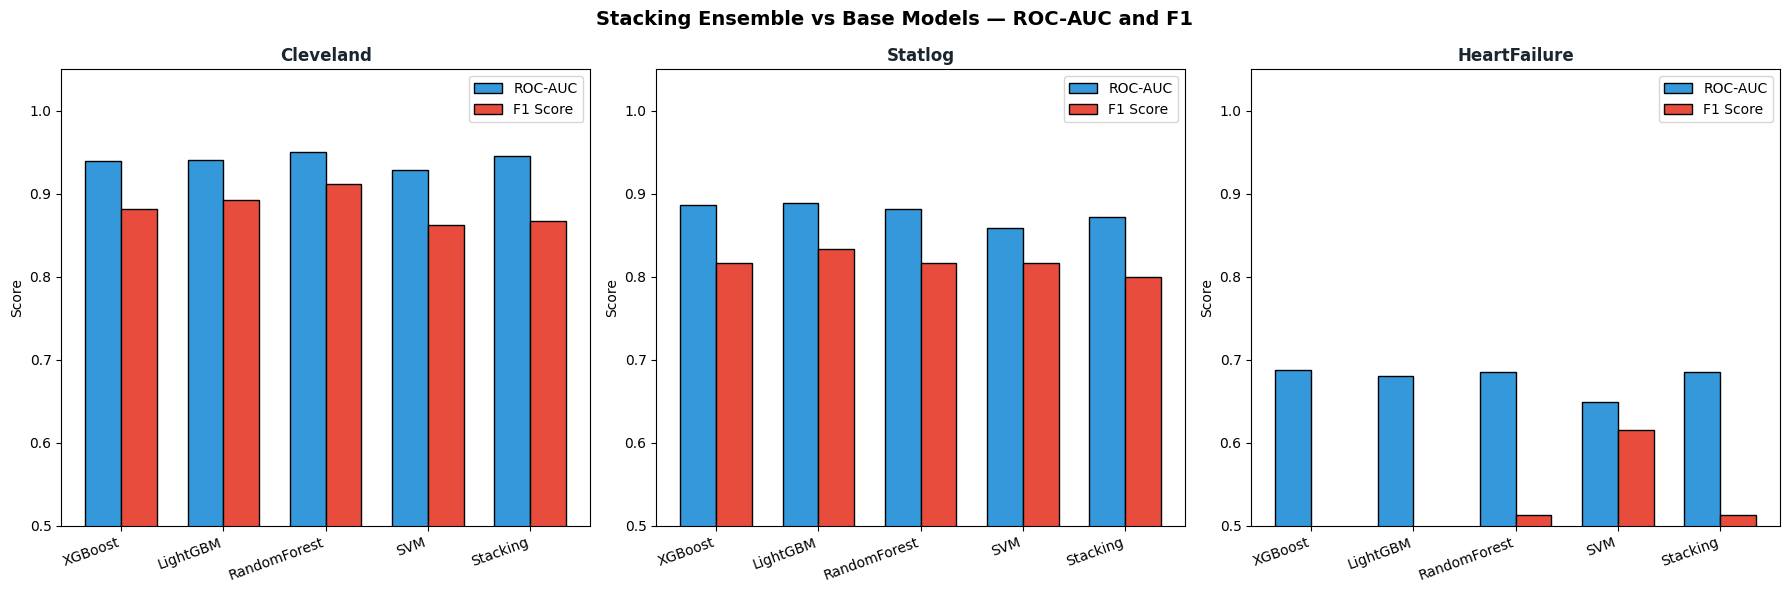

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, dataset_name in enumerate(dataset_registry.keys()):
    all_models = list(base_results[dataset_name].keys()) + ['Stacking']
    auc_scores = [base_results[dataset_name][m]['ROC-AUC']
                  for m in base_results[dataset_name].keys()]
    auc_scores.append(stacking_results[dataset_name]['ROC-AUC'])

    f1_scores = [base_results[dataset_name][m]['F1']
                 for m in base_results[dataset_name].keys()]
    f1_scores.append(stacking_results[dataset_name]['F1'])

    x = np.arange(len(all_models))
    width = 0.35

    axes[idx].bar(x - width/2, auc_scores, width, label='ROC-AUC',
                  color='#3498db', edgecolor='black')
    axes[idx].bar(x + width/2, f1_scores, width, label='F1 Score',
                  color='#e74c3c', edgecolor='black')

    # Highlight stacking bar
    axes[idx].get_children()[-4].set_color('#1a252f')
    axes[idx].get_children()[-3].set_color('#922b21')

    axes[idx].set_title(f'{dataset_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(all_models, rotation=20, ha='right')
    axes[idx].set_ylim(0.5, 1.05)
    axes[idx].legend()
    axes[idx].set_ylabel('Score')

plt.suptitle('Stacking Ensemble vs Base Models — ROC-AUC and F1',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'stacking_vs_base.png', dpi=300, bbox_inches='tight')
plt.show()

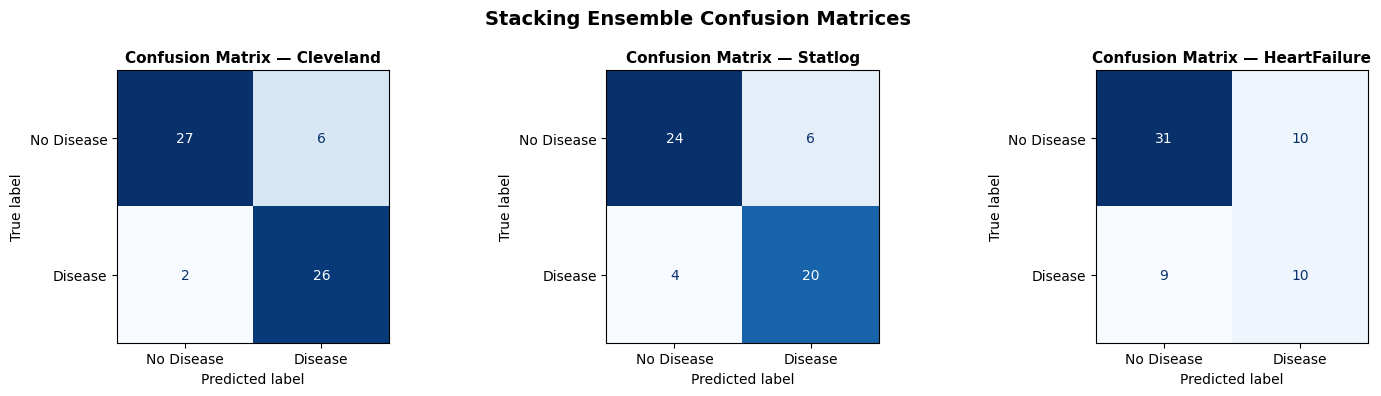

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, dataset_name in enumerate(dataset_registry.keys()):
    X_test = dataset_registry[dataset_name][2]
    y_test = dataset_registry[dataset_name][3]

    y_pred = stacking_models[dataset_name].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Disease', 'Disease'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'Confusion Matrix — {dataset_name}',
                        fontsize=11, fontweight='bold')

plt.suptitle('Stacking Ensemble Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# Apply calibration to stacking ensemble on all three datasets
# We compare Platt Scaling (sigmoid) vs Isotonic Regression

calibrated_models = {}

for dataset_name, (X_train, y_train, X_test, y_test) in dataset_registry.items():
    print(f"\nCalibrating stacking ensemble on {dataset_name}...")

    calibrated_platt = CalibratedClassifierCV(
        stacking_models[dataset_name],
        method='sigmoid',    # Platt Scaling
        cv='prefit'          # model already trained, just calibrate
    )
    calibrated_platt.fit(X_train, y_train)

    calibrated_isotonic = CalibratedClassifierCV(
        stacking_models[dataset_name],
        method='isotonic',   # Isotonic Regression
        cv='prefit'
    )
    calibrated_isotonic.fit(X_train, y_train)

    calibrated_models[dataset_name] = {
        'platt': calibrated_platt,
        'isotonic': calibrated_isotonic
    }

    print(f"  Calibration complete for {dataset_name}")

print("\nAll models calibrated.")


Calibrating stacking ensemble on Cleveland...
  Calibration complete for Cleveland

Calibrating stacking ensemble on Statlog...
  Calibration complete for Statlog

Calibrating stacking ensemble on HeartFailure...
  Calibration complete for HeartFailure

All models calibrated.


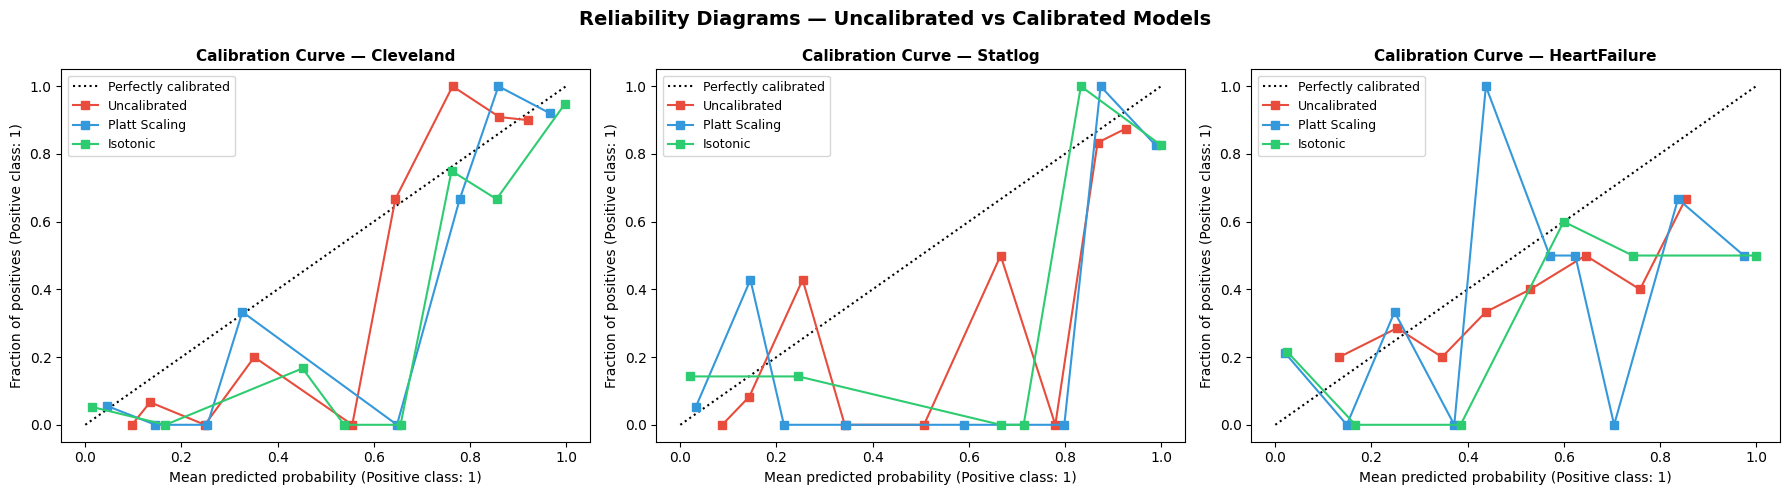

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, dataset_name in enumerate(dataset_registry.keys()):
    X_test = dataset_registry[dataset_name][2]
    y_test = dataset_registry[dataset_name][3]

    ax = axes[idx]

    # Uncalibrated stacking
    CalibrationDisplay.from_estimator(
        stacking_models[dataset_name],
        X_test, y_test,
        n_bins=10,
        name='Uncalibrated',
        ax=ax,
        color='#e74c3c'
    )

    # Platt scaling
    CalibrationDisplay.from_estimator(
        calibrated_models[dataset_name]['platt'],
        X_test, y_test,
        n_bins=10,
        name='Platt Scaling',
        ax=ax,
        color='#3498db'
    )

    # Isotonic regression
    CalibrationDisplay.from_estimator(
        calibrated_models[dataset_name]['isotonic'],
        X_test, y_test,
        n_bins=10,
        name='Isotonic',
        ax=ax,
        color='#2ecc71'
    )

    ax.set_title(f'Calibration Curve — {dataset_name}',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Reliability Diagrams — Uncalibrated vs Calibrated Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
brier_results = {}

for dataset_name, (X_train, y_train, X_test, y_test) in dataset_registry.items():
    uncal_prob = stacking_models[dataset_name].predict_proba(X_test)[:, 1]
    platt_prob = calibrated_models[dataset_name]['platt'].predict_proba(X_test)[:, 1]
    iso_prob   = calibrated_models[dataset_name]['isotonic'].predict_proba(X_test)[:, 1]

    brier_results[dataset_name] = {
        'Uncalibrated': round(brier_score_loss(y_test, uncal_prob), 4),
        'Platt Scaling': round(brier_score_loss(y_test, platt_prob), 4),
        'Isotonic':      round(brier_score_loss(y_test, iso_prob), 4)
    }

print("\n=== Brier Score Comparison (lower is better) ===\n")
brier_df = pd.DataFrame(brier_results).T
print(brier_df.to_string())

# Save to CSV for paper
brier_df.to_csv(OUTPUT_DIR + 'brier_scores.csv')


=== Brier Score Comparison (lower is better) ===

              Uncalibrated  Platt Scaling  Isotonic
Cleveland           0.0959         0.0947    0.1040
Statlog             0.1364         0.1554    0.1605
HeartFailure        0.2113         0.2634    0.2713


In [31]:
print("\n=== FINAL COMPREHENSIVE RESULTS ===\n")

all_rows = []

for dataset_name, (X_train, y_train, X_test, y_test) in dataset_registry.items():

    # Base models
    for model_name, metrics in base_results[dataset_name].items():
        all_rows.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Accuracy': metrics['Accuracy'],
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall'],
            'F1': metrics['F1'],
            'ROC-AUC': metrics['ROC-AUC'],
            'Brier Score': metrics['Brier']
        })

    # Stacking ensemble
    sm = stacking_results[dataset_name]
    all_rows.append({
        'Dataset': dataset_name,
        'Model': 'Stacking Ensemble',
        'Accuracy': sm['Accuracy'],
        'Precision': sm['Precision'],
        'Recall': sm['Recall'],
        'F1': sm['F1'],
        'ROC-AUC': sm['ROC-AUC'],
        'Brier Score': sm['Brier']
    })

    # Best calibrated model
    platt_prob = calibrated_models[dataset_name]['platt'].predict_proba(X_test)[:, 1]
    platt_pred = calibrated_models[dataset_name]['platt'].predict(X_test)

    all_rows.append({
        'Dataset': dataset_name,
        'Model': 'Stacking + Platt Calibration',
        'Accuracy': round(accuracy_score(y_test, platt_pred), 4),
        'Precision': round(precision_score(y_test, platt_pred), 4),
        'Recall': round(recall_score(y_test, platt_pred), 4),
        'F1': round(f1_score(y_test, platt_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, platt_prob), 4),
        'Brier Score': round(brier_score_loss(y_test, platt_prob), 4)
    })

final_df = pd.DataFrame(all_rows)
final_df = final_df.set_index(['Dataset', 'Model'])
print(final_df.to_string())

# Save for paper
final_df.to_csv(OUTPUT_DIR + 'final_results.csv')
print("\nResults saved to Drive.")


=== FINAL COMPREHENSIVE RESULTS ===

                                           Accuracy  Precision  Recall      F1  ROC-AUC  Brier Score
Dataset      Model                                                                                  
Cleveland    XGBoost                         0.8852     0.8387  0.9286  0.8814   0.9394       0.0934
             LightGBM                        0.9016     0.8929  0.8929  0.8929   0.9405       0.0903
             RandomForest                    0.9180     0.8966  0.9286  0.9123   0.9502       0.0984
             SVM                             0.8689     0.8333  0.8929  0.8621   0.9286       0.1174
             Stacking Ensemble               0.8689     0.8125  0.9286  0.8667   0.9459       0.0959
             Stacking + Platt Calibration    0.8689     0.8125  0.9286  0.8667   0.9459       0.0947
Statlog      XGBoost                         0.8333     0.8000  0.8333  0.8163   0.8861       0.1341
             LightGBM                        0.8519  

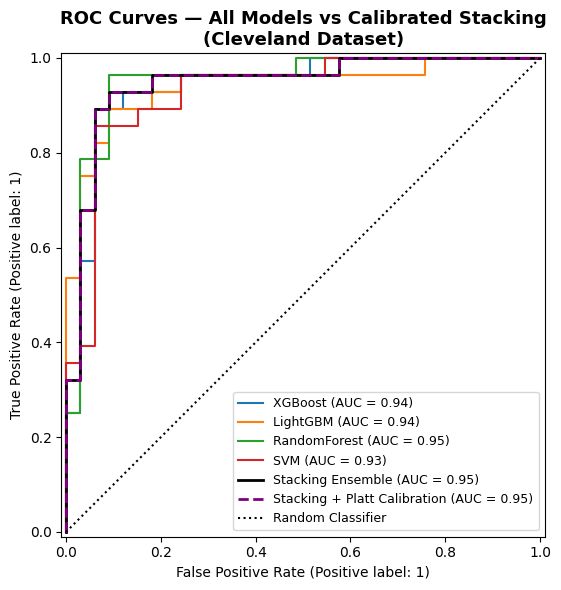

In [32]:
plt.figure(figsize=(9, 6))
ax = plt.gca()

X_test = dataset_registry['Cleveland'][2]
y_test = dataset_registry['Cleveland'][3]

# All base models
for model_name, model in tuned_models['Cleveland'].items():
    y_prob = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=model_name, ax=ax)

# Stacking
y_prob_stack = stacking_models['Cleveland'].predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_stack,
                                  name='Stacking Ensemble', ax=ax,
                                  color='black', lw=2)

# Calibrated stacking
y_prob_cal = calibrated_models['Cleveland']['platt'].predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_prob_cal,
                                  name='Stacking + Platt Calibration', ax=ax,
                                  color='purple', lw=2, linestyle='--')

plt.plot([0, 1], [0, 1], 'k:', label='Random Classifier')
plt.title('ROC Curves — All Models vs Calibrated Stacking\n(Cleveland Dataset)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'roc_final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# SHAP works best with tree-based models
# We use the XGBoost base model from Cleveland for SHAP analysis
# as it is the most interpretable with TreeExplainer

xgb_model = tuned_models['Cleveland']['XGBoost']
X_test_clev = dataset_registry['Cleveland'][2]
y_test_clev = dataset_registry['Cleveland'][3]

# Convert back to DataFrame for readable feature names
X_test_clev_df = pd.DataFrame(
    X_test_clev,
    columns=selected_features_clev
)

X_train_clev_df = pd.DataFrame(
    dataset_registry['Cleveland'][0],
    columns=selected_features_clev
)

# Create SHAP explainer
explainer_shap = shap.TreeExplainer(xgb_model)
shap_values = explainer_shap.shap_values(X_test_clev_df)

print("SHAP values computed.")
print("Shape of SHAP values:", np.array(shap_values).shape)

SHAP values computed.
Shape of SHAP values: (61, 8)


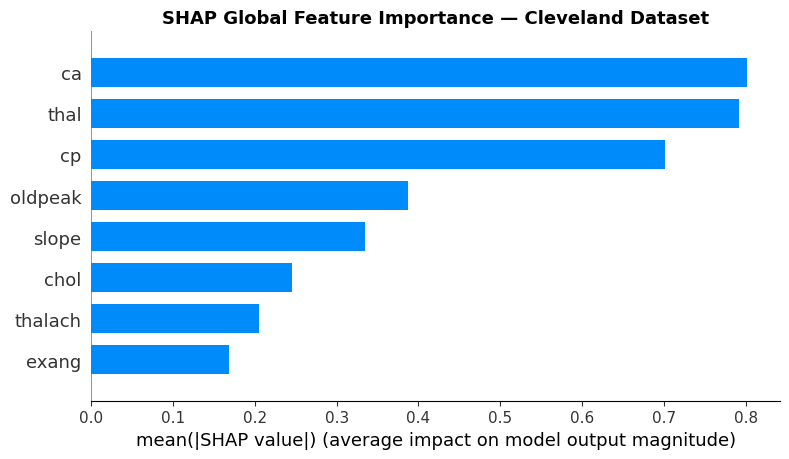

In [34]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_clev_df,
    plot_type='bar',
    show=False
)
plt.title('SHAP Global Feature Importance — Cleveland Dataset',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_global_bar.png', dpi=300, bbox_inches='tight')
plt.show()

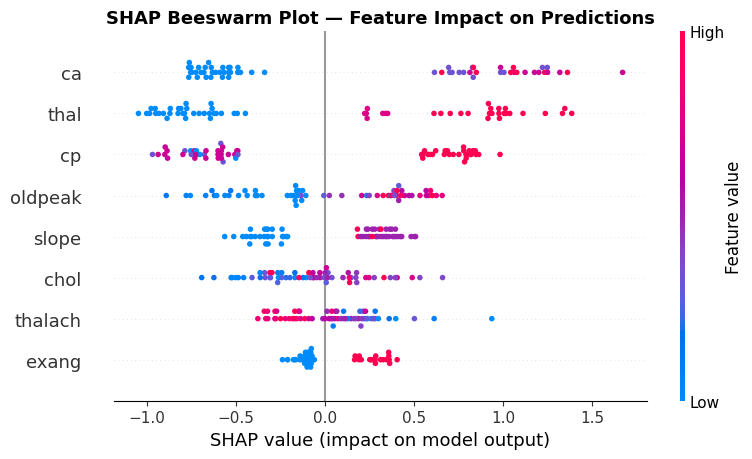

In [35]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_clev_df,
    show=False
)
plt.title('SHAP Beeswarm Plot — Feature Impact on Predictions',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

Explaining instance 51
Predicted probability of disease: 0.9847
Actual label: 1


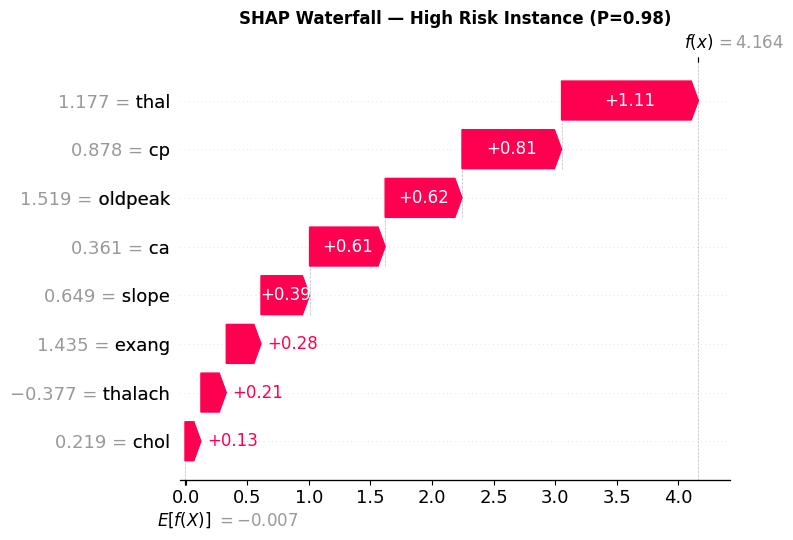

In [36]:
# Explain a single high-risk prediction
# Find an instance predicted as disease with high confidence
y_prob_xgb = xgb_model.predict_proba(X_test_clev_df)[:, 1]
high_risk_idx = np.argmax(y_prob_xgb)

print(f"Explaining instance {high_risk_idx}")
print(f"Predicted probability of disease: {y_prob_xgb[high_risk_idx]:.4f}")
print(f"Actual label: {y_test_clev.values[high_risk_idx]}")

# Waterfall plot for this instance
shap_explanation = explainer_shap(X_test_clev_df)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_explanation[high_risk_idx], show=False)
plt.title(f'SHAP Waterfall — High Risk Instance (P={y_prob_xgb[high_risk_idx]:.2f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_waterfall_highrisk.png', dpi=300, bbox_inches='tight')
plt.show()

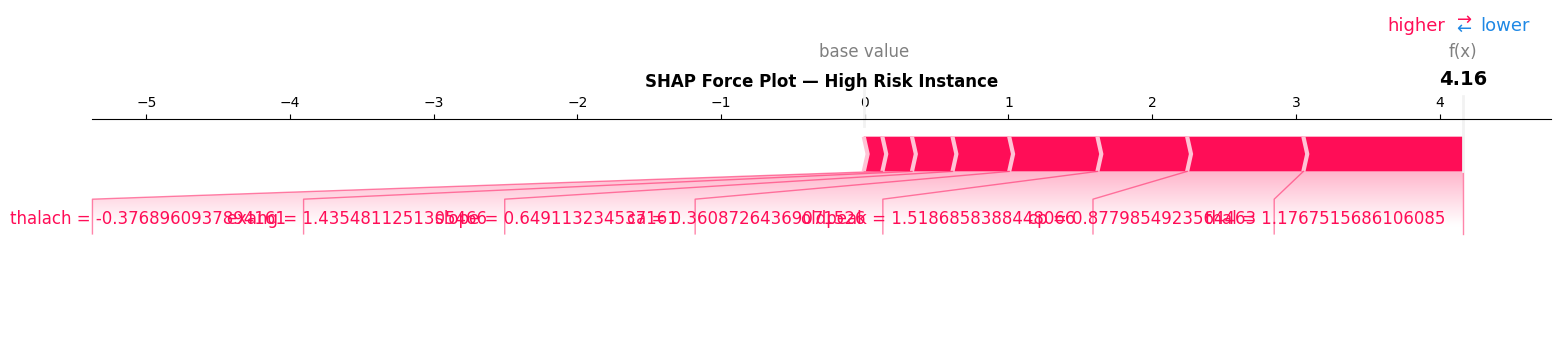

In [37]:
# Force plot for the same instance — good for paper figures
shap.initjs()

force_plot = shap.force_plot(
    explainer_shap.expected_value,
    shap_values[high_risk_idx],
    X_test_clev_df.iloc[high_risk_idx],
    show=False,
    matplotlib=True,
    figsize=(16, 4)
)

plt.title('SHAP Force Plot — High Risk Instance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_force_plot.png', dpi=300, bbox_inches='tight')
plt.show()

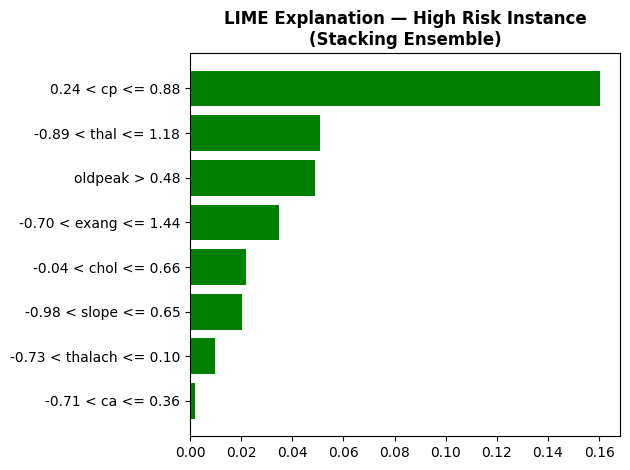


LIME Feature Contributions:
  0.24 < cp <= 0.88: 0.1602
  -0.89 < thal <= 1.18: 0.0510
  oldpeak > 0.48: 0.0488
  -0.70 < exang <= 1.44: 0.0346
  -0.04 < chol <= 0.66: 0.0218
  -0.98 < slope <= 0.65: 0.0204
  -0.73 < thalach <= 0.10: 0.0098
  -0.71 < ca <= 0.36: 0.0018


In [38]:
# LIME explains individual predictions by perturbing inputs locally
# Works model-agnostically — we apply it to the stacking ensemble

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=dataset_registry['Cleveland'][0],
    feature_names=selected_features_clev,
    class_names=['No Disease', 'Disease'],
    mode='classification',
    random_state=SEED
)

# Explain the same high-risk instance using stacking ensemble
stack_clev = stacking_models['Cleveland']

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_clev[high_risk_idx],
    predict_fn=stack_clev.predict_proba,
    num_features=len(selected_features_clev),
    num_samples=1000
)

# Plot
fig = lime_exp.as_pyplot_figure()
plt.title(f'LIME Explanation — High Risk Instance\n(Stacking Ensemble)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'lime_explanation.png', dpi=300, bbox_inches='tight')
plt.show()

# Print feature contributions
print("\nLIME Feature Contributions:")
for feat, weight in lime_exp.as_list():
    print(f"  {feat}: {weight:.4f}")

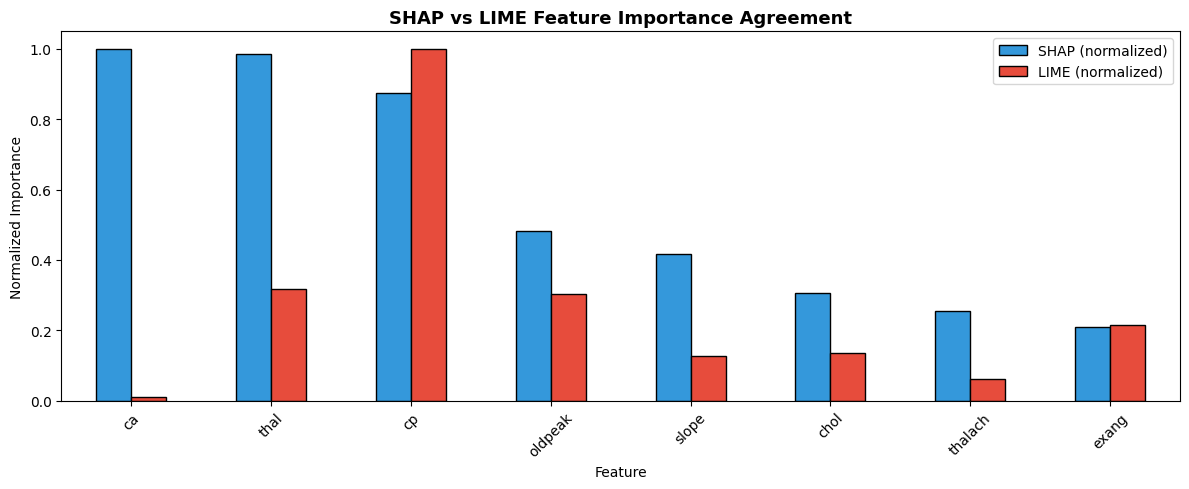


Feature Agreement Table:
         SHAP (normalized)  LIME (normalized)
ca                1.000000           0.011244
thal              0.986725           0.318184
cp                0.874792           1.000000
oldpeak           0.483197           0.304508
slope             0.416876           0.127368
chol              0.305759           0.136346
thalach           0.254886           0.061213
exang             0.209257           0.216321


In [39]:
# Compare which features both SHAP and LIME agree are important
# Agreement between two XAI methods strengthens your paper significantly

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=selected_features_clev
).sort_values(ascending=False)

lime_contributions = dict(lime_exp.as_list())
lime_clean = {}
for feat in selected_features_clev:
    matched = [v for k, v in lime_contributions.items() if feat in k]
    lime_clean[feat] = abs(matched[0]) if matched else 0

lime_importance = pd.Series(lime_clean).reindex(selected_features_clev).fillna(0)

# Normalize both to 0-1 for fair comparison
shap_norm = shap_importance / shap_importance.max()
lime_norm = lime_importance / lime_importance.max() if lime_importance.max() > 0 else lime_importance

agreement_df = pd.DataFrame({
    'SHAP (normalized)': shap_norm,
    'LIME (normalized)': lime_norm
}).sort_values('SHAP (normalized)', ascending=False)

agreement_df.plot(kind='bar', figsize=(12, 5), color=['#3498db', '#e74c3c'],
                  edgecolor='black')
plt.title('SHAP vs LIME Feature Importance Agreement',
          fontsize=13, fontweight='bold')
plt.ylabel('Normalized Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'shap_lime_agreement.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature Agreement Table:")
print(agreement_df.to_string())

In [40]:
# DiCE answers: "What would need to change for this patient
# to be classified as No Disease?"

# DiCE requires a specific data format
X_train_dice = pd.DataFrame(
    dataset_registry['Cleveland'][0],
    columns=selected_features_clev
)
y_train_dice = dataset_registry['Cleveland'][1].reset_index(drop=True)
train_dice_full = X_train_dice.copy()
train_dice_full['target'] = y_train_dice.values

# Define DiCE data object
d = dice_ml.Data(
    dataframe=train_dice_full,
    continuous_features=selected_features_clev,
    outcome_name='target'
)

# Wrap stacking model for DiCE
m = dice_ml.Model(
    model=stacking_models['Cleveland'],
    backend='sklearn'
)

# Create DiCE explainer
exp_dice = dice_ml.Dice(d, m, method='random')

# Generate counterfactuals for the high risk instance
query_instance = X_test_clev_df.iloc[[high_risk_idx]]

print(f"Generating counterfactuals for instance {high_risk_idx}...")
print(f"Original prediction: Disease (P={y_prob_xgb[high_risk_idx]:.2f})")
print(f"\nOriginal feature values:")
print(query_instance.to_string())

Generating counterfactuals for instance 51...
Original prediction: Disease (P=0.98)

Original feature values:
        thal        ca        cp   oldpeak     exang     slope      chol   thalach
51  1.176752  0.360873  0.877985  1.518686  1.435481  0.649113  0.218739 -0.376896


In [41]:
# Generate 3 counterfactual examples
dice_exp = exp_dice.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class='opposite',
    random_seed=SEED
)

# Display counterfactuals
print("\n=== COUNTERFACTUAL EXPLANATIONS ===")
print("These are the minimal changes needed to flip the prediction to No Disease:\n")
dice_exp.visualize_as_dataframe(show_only_changes=True)

# Save counterfactuals to CSV
cf_df = dice_exp.cf_examples_list[0].final_cfs_df
cf_df.to_csv(OUTPUT_DIR + 'counterfactuals.csv', index=False)
print("\nCounterfactuals saved.")

100%|██████████| 1/1 [00:00<00:00,  3.77it/s]


=== COUNTERFACTUAL EXPLANATIONS ===
These are the minimal changes needed to flip the prediction to No Disease:

Query instance (original outcome : 1)


,thal,ca,cp,oldpeak,exang,slope,chol,thalach,target
0,1.176752,0.360873,0.877985,1.518686,1.435481,0.649113,0.218739,-0.376896,1



Diverse Counterfactual set (new outcome: 0)


,thal,ca,cp,oldpeak,exang,slope,chol,thalach,target
0,-,-0.6648418,-2.2067264,-,-,-0.92955992,-,-,0.0
1,-0.72806963,-,-2.0062249,-0.47722109,-,-,-,-,0.0
2,-0.88066382,-,-2.2372774,-,-,-0.96129377,-,-,0.0



Counterfactuals saved.


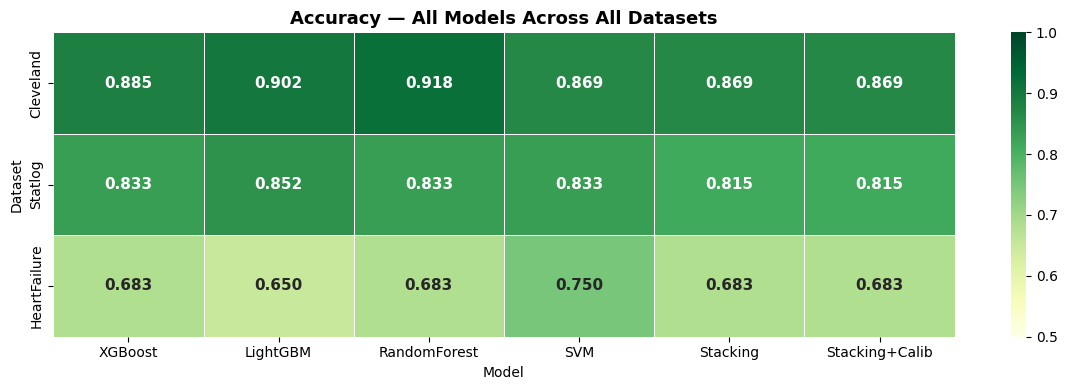

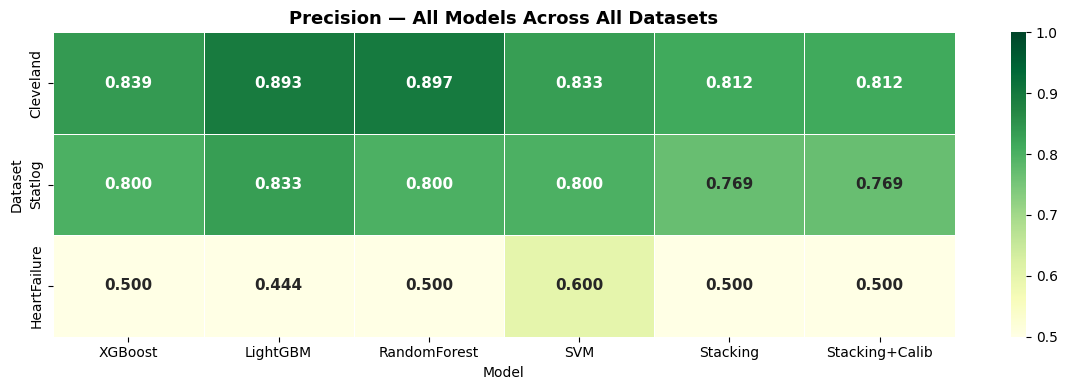

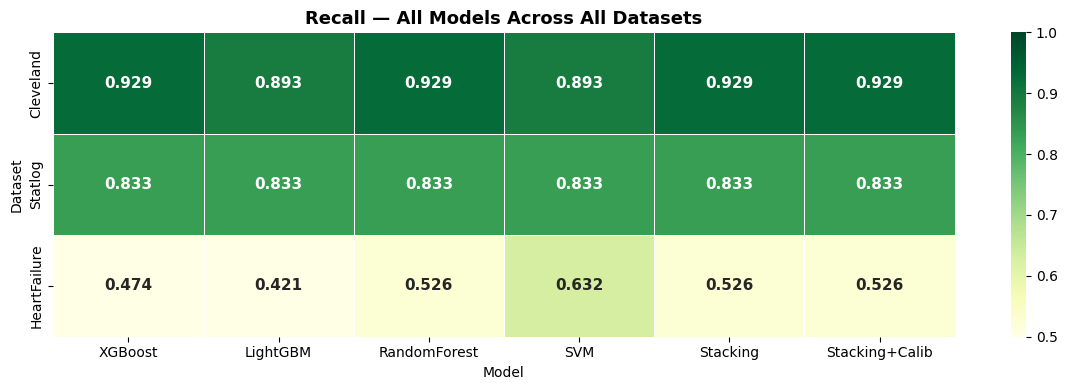

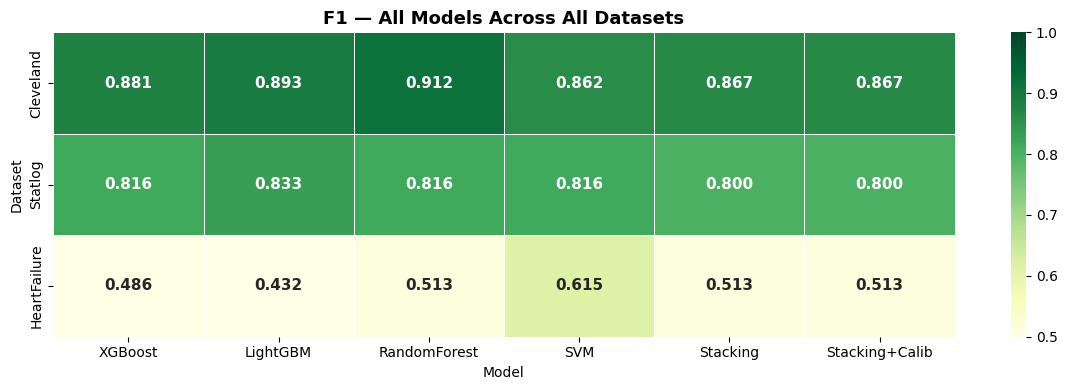

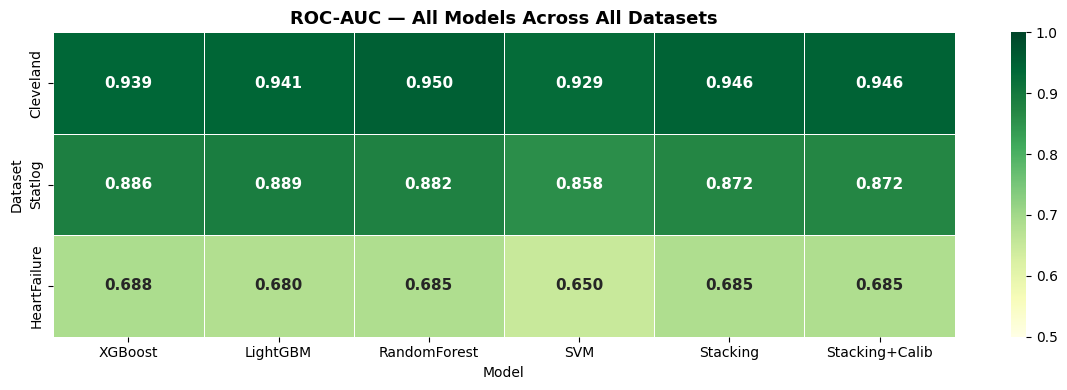

In [42]:
# Create a comprehensive performance heatmap
# This is a strong single figure that summarizes your entire results section

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

for metric in metrics_list:
    rows = {}

    for dataset_name in dataset_registry.keys():
        row = {}
        for model_name in base_results[dataset_name].keys():
            row[model_name] = base_results[dataset_name][model_name][metric]
        row['Stacking'] = stacking_results[dataset_name][metric]

        # Add calibrated stacking
        X_test = dataset_registry[dataset_name][2]
        y_test = dataset_registry[dataset_name][3]
        platt_prob = calibrated_models[dataset_name]['platt'].predict_proba(X_test)[:, 1]
        platt_pred = calibrated_models[dataset_name]['platt'].predict(X_test)

        if metric == 'Accuracy':
            row['Stacking+Calib'] = round(accuracy_score(y_test, platt_pred), 4)
        elif metric == 'Precision':
            row['Stacking+Calib'] = round(precision_score(y_test, platt_pred), 4)
        elif metric == 'Recall':
            row['Stacking+Calib'] = round(recall_score(y_test, platt_pred), 4)
        elif metric == 'F1':
            row['Stacking+Calib'] = round(f1_score(y_test, platt_pred), 4)
        elif metric == 'ROC-AUC':
            row['Stacking+Calib'] = round(roc_auc_score(y_test, platt_prob), 4)

        rows[dataset_name] = row

    heatmap_df = pd.DataFrame(rows).T

    plt.figure(figsize=(12, 4))
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlGn',
                linewidths=0.5, vmin=0.5, vmax=1.0,
                annot_kws={'size': 11, 'weight': 'bold'})
    plt.title(f'{metric} — All Models Across All Datasets',
              fontsize=13, fontweight='bold')
    plt.xlabel('Model')
    plt.ylabel('Dataset')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + f'heatmap_{metric.lower()}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

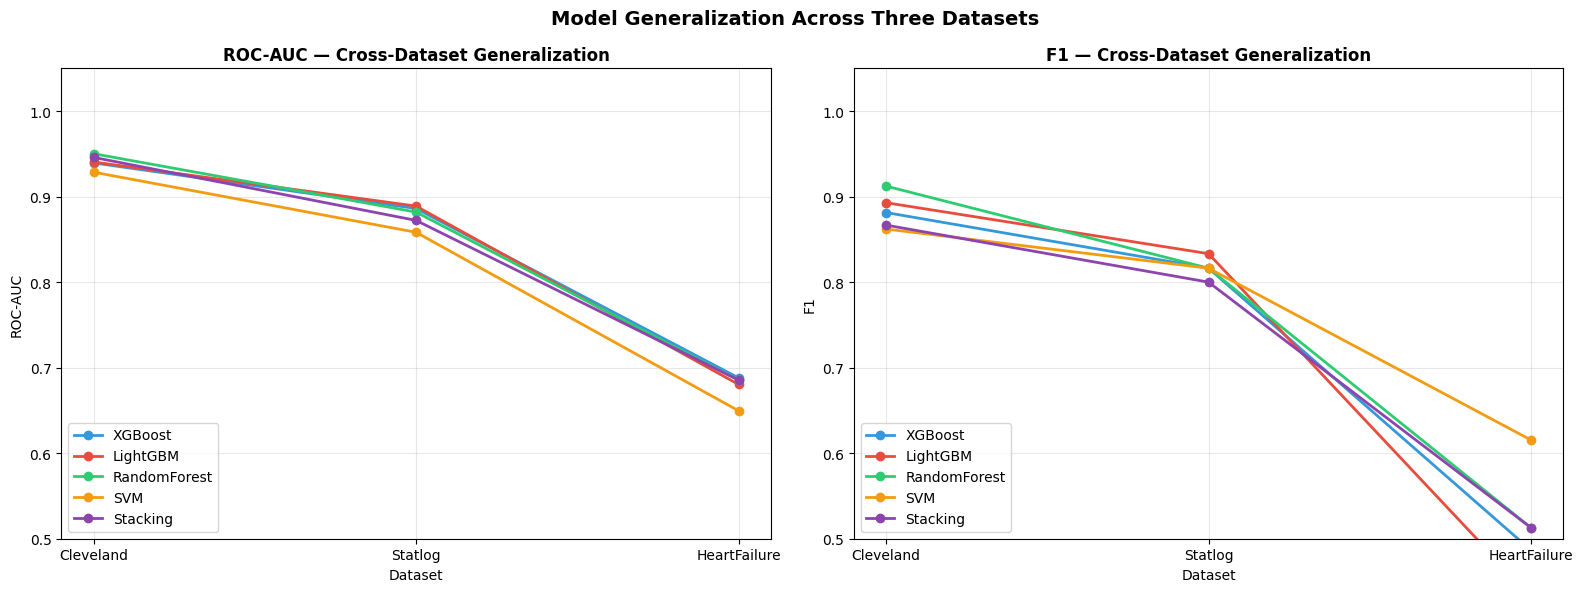

In [43]:
# This plot shows whether your stacking ensemble generalizes
# across datasets — key visual proof of your multi-dataset contribution

models_to_compare = ['XGBoost', 'LightGBM', 'RandomForest', 'SVM', 'Stacking']
dataset_names = list(dataset_registry.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, metric in enumerate(['ROC-AUC', 'F1']):
    for m_idx, model_name in enumerate(models_to_compare):
        scores = []
        for dataset_name in dataset_names:
            if model_name == 'Stacking':
                scores.append(stacking_results[dataset_name][metric])
            else:
                scores.append(base_results[dataset_name][model_name][metric])

        axes[ax_idx].plot(dataset_names, scores,
                         marker='o', linewidth=2,
                         label=model_name,
                         color=colors[m_idx])

    axes[ax_idx].set_title(f'{metric} — Cross-Dataset Generalization',
                           fontsize=12, fontweight='bold')
    axes[ax_idx].set_ylabel(metric)
    axes[ax_idx].set_xlabel('Dataset')
    axes[ax_idx].legend(loc='lower left')
    axes[ax_idx].set_ylim(0.5, 1.05)
    axes[ax_idx].grid(True, alpha=0.3)

plt.suptitle('Model Generalization Across Three Datasets',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'cross_dataset_generalization.png',
            dpi=300, bbox_inches='tight')
plt.show()

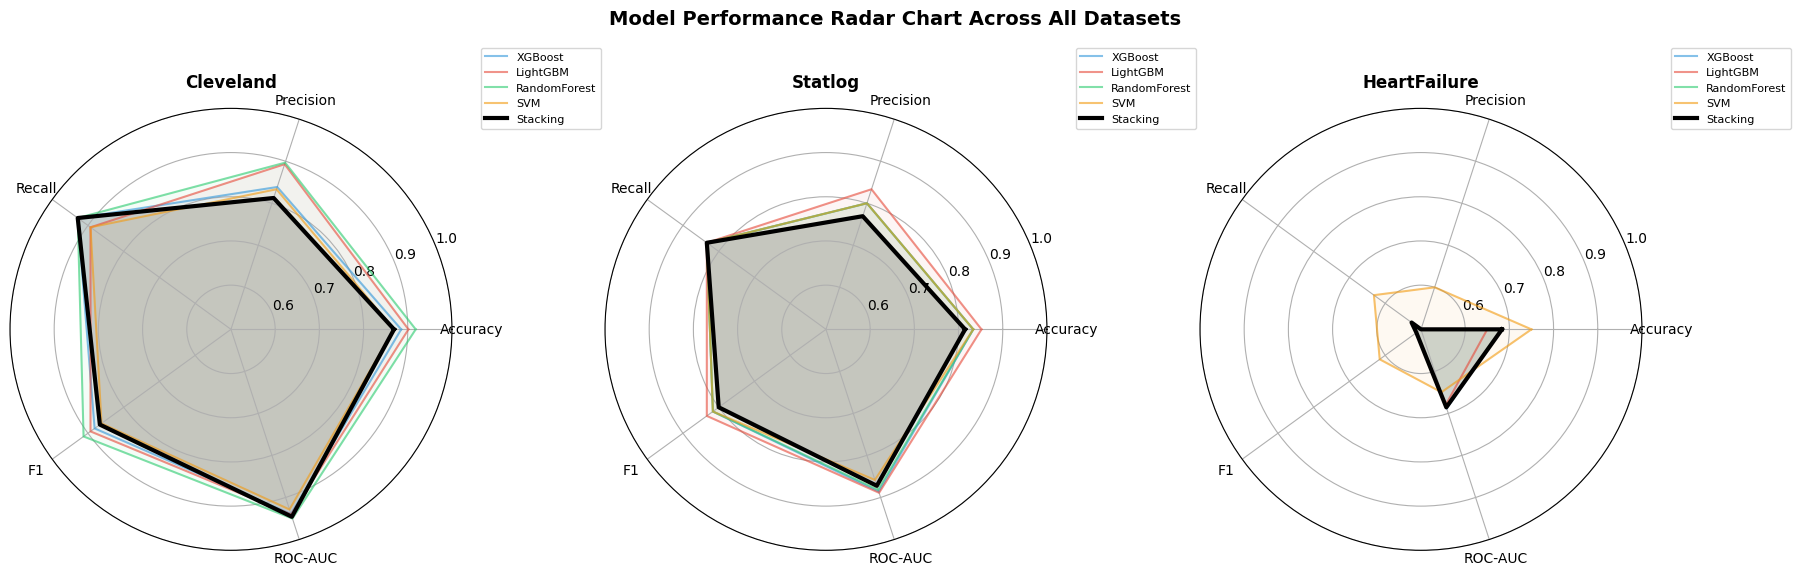

In [44]:
# Radar chart gives a holistic view of your best model
# across all metrics — commonly seen in top IEEE papers

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
num_vars = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          subplot_kw=dict(polar=True))

colors_radar = ['#3498db', '#e74c3c', '#2ecc71',
                '#f39c12', '#8e44ad', '#1abc9c']

for idx, dataset_name in enumerate(dataset_registry.keys()):
    ax = axes[idx]

    # Plot base models
    for m_idx, model_name in enumerate(base_results[dataset_name].keys()):
        values = [base_results[dataset_name][model_name][m]
                  for m in metrics_radar]
        values += values[:1]
        ax.plot(angles, values, linewidth=1.5,
                label=model_name, color=colors_radar[m_idx], alpha=0.6)
        ax.fill(angles, values, alpha=0.05, color=colors_radar[m_idx])

    # Plot stacking — highlighted
    stack_vals = [stacking_results[dataset_name][m] for m in metrics_radar]
    stack_vals += stack_vals[:1]
    ax.plot(angles, stack_vals, linewidth=3,
            label='Stacking', color='black')
    ax.fill(angles, stack_vals, alpha=0.15, color='black')

    ax.set_thetagrids(np.degrees(angles[:-1]), metrics_radar)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(f'{dataset_name}', fontsize=12,
                 fontweight='bold', pad=15)
    ax.legend(loc='upper right',
              bbox_to_anchor=(1.35, 1.15), fontsize=8)

plt.suptitle('Model Performance Radar Chart Across All Datasets',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
# Clean formatted table for direct use in your paper

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY — READY FOR PAPER")
print("="*80)

summary_rows = []

for dataset_name in dataset_registry.keys():
    X_test = dataset_registry[dataset_name][2]
    y_test = dataset_registry[dataset_name][3]

    for model_name in base_results[dataset_name].keys():
        m = base_results[dataset_name][model_name]
        summary_rows.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Acc': m['Accuracy'],
            'Prec': m['Precision'],
            'Rec': m['Recall'],
            'F1': m['F1'],
            'AUC': m['ROC-AUC'],
            'Brier': m['Brier']
        })

    # Stacking
    s = stacking_results[dataset_name]
    summary_rows.append({
        'Dataset': dataset_name,
        'Model': 'Stacking Ensemble',
        'Acc': s['Accuracy'],
        'Prec': s['Precision'],
        'Rec': s['Recall'],
        'F1': s['F1'],
        'AUC': s['ROC-AUC'],
        'Brier': s['Brier']
    })

    # Calibrated stacking
    platt_prob = calibrated_models[dataset_name]['platt'].predict_proba(X_test)[:, 1]
    platt_pred = calibrated_models[dataset_name]['platt'].predict(X_test)
    summary_rows.append({
        'Dataset': dataset_name,
        'Model': 'Stacking + Calibration',
        'Acc': round(accuracy_score(y_test, platt_pred), 4),
        'Prec': round(precision_score(y_test, platt_pred), 4),
        'Rec': round(recall_score(y_test, platt_pred), 4),
        'F1': round(f1_score(y_test, platt_pred), 4),
        'AUC': round(roc_auc_score(y_test, platt_prob), 4),
        'Brier': round(brier_score_loss(y_test, platt_prob), 4)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index(['Dataset', 'Model'])
print(summary_df.to_string())

summary_df.to_csv(OUTPUT_DIR + 'paper_results_table.csv')
print("\nSaved to Drive as paper_results_table.csv")


FINAL RESULTS SUMMARY — READY FOR PAPER
                                        Acc    Prec     Rec      F1     AUC   Brier
Dataset      Model                                                                 
Cleveland    XGBoost                 0.8852  0.8387  0.9286  0.8814  0.9394  0.0934
             LightGBM                0.9016  0.8929  0.8929  0.8929  0.9405  0.0903
             RandomForest            0.9180  0.8966  0.9286  0.9123  0.9502  0.0984
             SVM                     0.8689  0.8333  0.8929  0.8621  0.9286  0.1174
             Stacking Ensemble       0.8689  0.8125  0.9286  0.8667  0.9459  0.0959
             Stacking + Calibration  0.8689  0.8125  0.9286  0.8667  0.9459  0.0947
Statlog      XGBoost                 0.8333  0.8000  0.8333  0.8163  0.8861  0.1341
             LightGBM                0.8519  0.8333  0.8333  0.8333  0.8889  0.1286
             RandomForest            0.8333  0.8000  0.8333  0.8163  0.8819  0.1362
             SVM                   

In [46]:
# Confirm everything saved correctly to Drive

print("\n=== ALL FILES SAVED TO DRIVE ===\n")
saved_files = os.listdir(OUTPUT_DIR)
saved_files.sort()
for f in saved_files:
    size = os.path.getsize(OUTPUT_DIR + f)
    print(f"  {f} ({size/1024:.1f} KB)")

print(f"\nTotal files: {len(saved_files)}")
print(f"Location: {OUTPUT_DIR}")


=== ALL FILES SAVED TO DRIVE ===

  base_model_comparison.png (162.9 KB)
  brier_scores.csv (0.1 KB)
  calibration_curves.png (479.9 KB)
  class_distribution.png (157.4 KB)
  confusion_matrices.png (120.5 KB)
  correlation_heatmap.png (370.0 KB)
  counterfactuals.csv (0.4 KB)
  cross_dataset_generalization.png (413.9 KB)
  feature_distributions.png (234.0 KB)
  final_results.csv (1.2 KB)
  heatmap_accuracy.png (142.9 KB)
  heatmap_f1.png (142.5 KB)
  heatmap_precision.png (142.2 KB)
  heatmap_recall.png (128.9 KB)
  heatmap_roc-auc.png (155.1 KB)
  lime_explanation.png (114.3 KB)
  mutual_information.png (134.2 KB)
  paper_results_table.csv (1.1 KB)
  radar_chart.png (812.8 KB)
  roc_curves_base_models.png (143.6 KB)
  roc_final_comparison.png (196.3 KB)
  shap_beeswarm.png (206.7 KB)
  shap_force_plot.png (158.7 KB)
  shap_global_bar.png (105.3 KB)
  shap_lime_agreement.png (133.1 KB)
  shap_waterfall_highrisk.png (154.4 KB)
  stacking_vs_base.png (171.9 KB)

Total files: 27
Location